# 301 · Backtesting & Evaluation

Before deploying a new sequential design (like GSD or AVI) to production, you should verify its performance on historical data. This process, called **Backtesting**, allows you to answer questions like:
- "How much earlier would we have stopped on this past experiment?"
- "Would we have made a different decision?"

In this tutorial, we will:
- Load the **ASOS Online-Controlled-Experiment dataset**.
- Run a historical simulation using the unified `backtest()` API.

## 1. Data Preparation

We use the open ASOS digital experiments dataset. We'll pick one experiment and extract incremental batches.

In [1]:
from pathlib import Path

import ibis
import pandas as pd

from earlysign.controllers.GST_Spending_JennisonTurnbull2000 import (
    JennisonTurnbull2000Controller,
)
from earlysign.core.ledger import Ledger

# Download dataset if needed
data_path = Path("data/asos_digital_experiments_dataset.parquet")
if not data_path.exists():
    data_path.parent.mkdir(parents=True, exist_ok=True)
    !wget -O {data_path} https://osf.io/62t7f/download

df_raw = pd.read_parquet(data_path)
exp_id = "5ca6d6"

# NOTE: For backtesting, we must filter for a specific test group (variant_id)
# because the dataset may contain multiple treatments for the same experiment.
df = df_raw[
    (df_raw["experiment_id"] == exp_id)
    & (df_raw["metric_id"] == 1)
    & (df_raw["variant_id"] == 1)
].copy()

print(f"Loaded {len(df)} monitoring steps for experiment {exp_id} (variant 1).")

Loaded 60 monitoring steps for experiment 5ca6d6 (variant 1).


## 2. Preparing a Backtest Table

The `backtest_from_table()` API expects an Ibis table with columns for arm names, sample sizes, and successes.

In [2]:
df = df.sort_values("time_since_start")
# Calculate increments between monitoring steps
df["dn_c"] = df["count_c"].diff().fillna(df["count_c"]).astype(int)
df["ds_c"] = (
    (df["count_c"] * df["mean_c"]).diff().fillna(df["count_c"] * df["mean_c"])
).astype(int)
df["dn_t"] = df["count_t"].diff().fillna(df["count_t"]).astype(int)
df["ds_t"] = (
    (df["count_t"] * df["mean_t"]).diff().fillna(df["count_t"] * df["mean_t"])
).astype(int)

# Convert to long-format table for Ibis
df_long = pd.concat(
    [
        df[["time_since_start", "dn_c", "ds_c"]]
        .rename(columns={"dn_c": "total", "ds_c": "success"})
        .assign(arm="control"),
        df[["time_since_start", "dn_t", "ds_t"]]
        .rename(columns={"dn_t": "total", "ds_t": "success"})
        .assign(arm="treatment"),
    ]
).sort_values("time_since_start")

tbl_events = ibis.memtable(df_long)
tbl_events.head().execute()

,time_since_start,total,success,arm
0,1.5,9114,1990,control
1,1.5,9130,1947,treatment
2,2.0,4633,1458,control
3,2.0,4742,1542,treatment
4,2.5,2649,788,control


## 3. Running the Backtest

The `backtest_from_table()` API expects an Ibis table with columns for arm names, sample sizes, and successes.
We initialize a design (GSD) and run the backtest. The controller will process the table as if it were arriving in real-time.

In [3]:
ledger = Ledger(ibis.connect("duckdb://:memory:"), "backtest")
ledger.ensure()
trial = JennisonTurnbull2000Controller(ledger)

# Design a protocol based on baseline rates from the data
p_baseline = df.iloc[0]["mean_c"]
protocol = trial.design(
    p_control=p_baseline,
    effect_spec={"kind": "relative_improvement", "value": 0.05},
    alpha=0.05,
    power=0.8,
    looks=5,
)
trial.set_protocol(protocol)

print("Starting backtest...")
# Specify column names
results = trial.backtest_from_table(
    tbl_events,
    arm_col="arm",
    total_col="total",
    success_col="success",
    order_by="time_since_start",
)

print(f"Backtest Final Status: {results['final_status']}")
print(f"Sample Size at Stop: {results['sample_n']:,}")

Starting backtest...
2026-03-02 23:08:15 [INFO] earlysign.controllers.GST_Spending_JennisonTurnbull2000: Stopping criterion met at step 3.0000000000000004: stop_plan_end_reached
Backtest Final Status: stop_plan_end_reached
Sample Size at Stop: 37,590


## 4. Visualizing Backtest Results

Just as we did in the GSD tutorial, we can visualize the operating characteristics of the design and the trajectory of the test statistic during the backtest.

{'summary': None, 'figure': <Figure size 1000x600 with 1 Axes>}
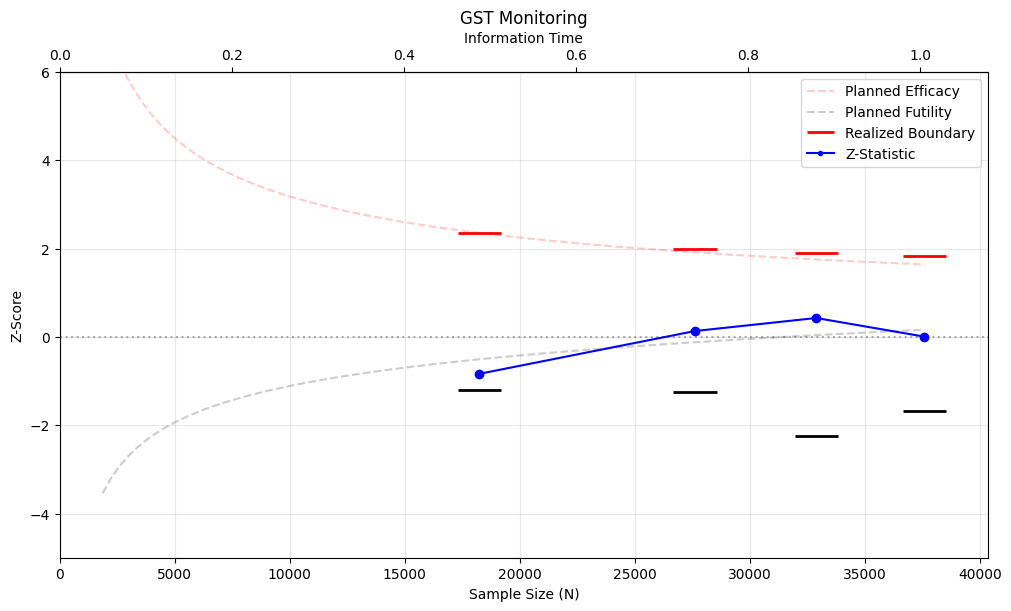

,Effect Size (%),Power,Expected N,Fixed N (Ref),ESS / Fixed (%),ESS / Max (%),Max N (Total),Prob > Fixed N,Prob Stop (Look 1),Prob Stop (Look 2),Prob Stop (Look 3),Prob Stop (Look 4),Prob Stop (Look 5)
0,-20.000000,0.0%,13982.3,35412.7,39.5%,37.4%,37416.0,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%
1,-15.000000,0.0%,13982.3,35412.7,39.5%,37.4%,37416.0,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%
2,-10.000000,0.0%,13984.1,35412.7,39.5%,37.4%,37416.0,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%
3,-5.000000,0.0%,14278.2,35412.7,40.3%,38.2%,37416.0,0.0%,96.0%,3.5%,0.5%,0.1%,0.0%
4,0.000000,4.4%,19208.9,35412.7,54.2%,51.3%,37416.0,7.7%,57.3%,18.5%,9.5%,6.9%,7.7%
5,5.000000,76.0%,24445.4,35412.7,69.0%,65.3%,37416.0,17.4%,22.2%,27.5%,16.1%,16.8%,17.4%
6,10.000000,99.8%,16403.4,35412.7,46.3%,43.8%,37416.0,0.2%,68.4%,25.7%,4.2%,1.6%,0.2%
7,15.000000,100.0%,14105.0,35412.7,39.8%,37.7%,37416.0,0.0%,98.1%,1.9%,0.0%,0.0%,0.0%
8,20.000000,100.0%,13982.3,35412.7,39.5%,37.4%,37416.0,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%
9,25.000000,100.0%,13982.3,35412.7,39.5%,37.4%,37416.0,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%

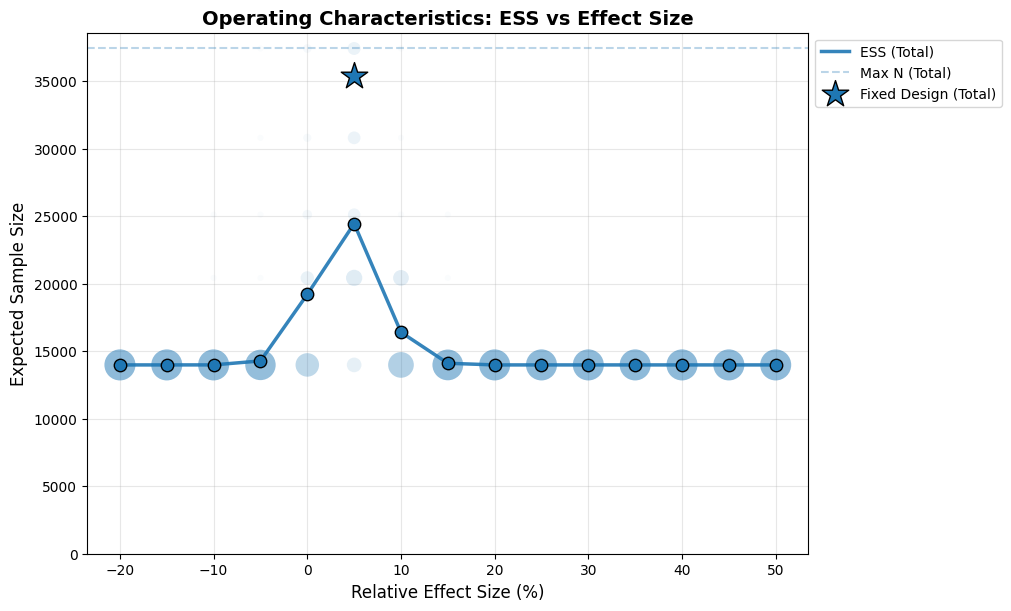

In [4]:
import matplotlib.pyplot as plt
from earlysign.methods.group_sequential.reporting.visualization import (
    visualize_protocol_design,
)

# 1. Visualize the design (OC)
res = visualize_protocol_design(protocol, effect_sizes=list(range(-20, 50 + 5, 5)))


# 2. Visualize the trajectory of the backtest
display(trial.plot_result())
res

## 5. Summary

- **Evaluation**: Backtesting provides empirical evidence that a design is suitable for your specific data distribution.
- **Comparison**: You can run multiple backtests with different controllers (GSD vs mSPRT) to see which would have performed better.
- **Continuity**: The same code used for backtesting can be used for live orchestration.

In the final tutorial, we will learn how to deploy these designs to **BigQuery** for production usage.